In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Đọc file dữ liệu ĐÃ LÀM SẠCH
df_clean = pd.read_csv('Diab_pyth_data_clean.csv')

# Xem thử 5 dòng đầu tiên
display(df_clean.head())

,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,time.ppn,BMI,diabetes_status
0,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,29.0,38.0,720.0,22.128772,Normal
1,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,46.0,48.0,360.0,37.415527,Normal
2,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,49.0,57.0,180.0,48.365493,Normal
3,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,33.0,38.0,480.0,18.635999,Normal
4,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,44.0,41.0,300.0,27.822016,Diabetes


In [15]:
# 1. Tạo biến mục tiêu mới: glyhb >= 6.5 là Có bệnh (1), ngược lại là Không bệnh (0)
df_clean['diabetes'] = df_clean['glyhb'].apply(lambda x: 1 if x >= 6.5 else 0)

print("Số lượng bệnh nhân phân theo nhóm:")
print(df_clean['diabetes'].value_counts())

# 2. Loại bỏ các cột không dùng đến để tránh học vẹt
X = df_clean.drop(columns=['diabetes', 'glyhb', 'diabetes_status'])
y = df_clean['diabetes']

# 3. Mã hóa One-Hot cho các biến phân loại (ra 0 và 1)
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

Số lượng bệnh nhân phân theo nhóm:
diabetes
0    325
1     65
Name: count, dtype: int64


=== ĐỘ CHÍNH XÁC TỔNG THỂ (ACCURACY): 85.90% ===

=== BÁO CÁO PHÂN LOẠI CHI TIẾT ===
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        65
           1       0.62      0.38      0.48        13

    accuracy                           0.86        78
   macro avg       0.76      0.67      0.70        78
weighted avg       0.84      0.86      0.84        78



C:\Users\USER\AppData\Local\Temp\ipykernel_24900\3020672356.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')


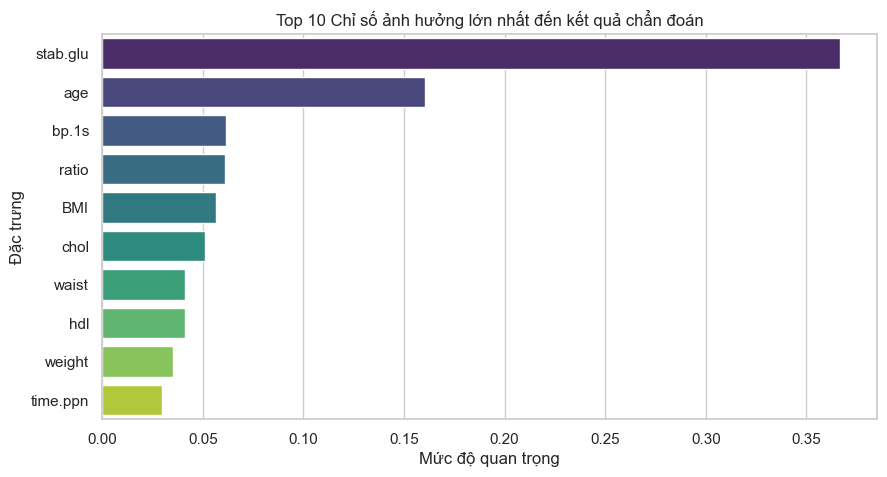

In [16]:
# 1. Chia tập dữ liệu (80% học - 20% thi)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Huấn luyện mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 3. Đánh giá mô hình
y_pred = rf_model.predict(X_test)

# --- IN ĐỘ CHÍNH XÁC (ACCURACY) ---
accuracy = accuracy_score(y_test, y_pred)
print(f"=== ĐỘ CHÍNH XÁC TỔNG THỂ (ACCURACY): {accuracy * 100:.2f}% ===\n")

print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT ===")
print(classification_report(y_test, y_pred))

# 4. Vẽ biểu đồ các biến dự báo mạnh nhất (Top Predictors)
importances = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Chỉ số ảnh hưởng lớn nhất đến kết quả chẩn đoán')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

In [17]:
import joblib

# 1. Đặt tên cho file mô hình
model_filename = 'diabetes_rf_model.pkl'

# 2. Lưu mô hình rf_model đã huấn luyện xong xuống ổ cứng
joblib.dump(rf_model, model_filename)

print(f"=== ĐÃ LƯU MÔ HÌNH THÀNH CÔNG ===")
print(f"File lưu tại: {model_filename}")
# loaded_model = joblib.load('diabetes_rf_model.pkl')
# ket_qua = loaded_model.predict(X_benh_nhan_moi)

=== ĐÃ LƯU MÔ HÌNH THÀNH CÔNG ===
File lưu tại: diabetes_rf_model.pkl
